In [41]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from typing import Union
from scipy.stats import norm


In [42]:
BASE_DIR = 'D:/Leonardo/UDESA - CENTRO Cuantitativo/EPU ARG/src'
save_results_dir = Path(BASE_DIR).parent / "data" 
results_file = save_results_dir / "epu_argentina_key_words_gdelt_maped_jp_maped_all_media_with_sentiment.csv"

df = pd.read_csv(results_file)
df['fecha'] = pd.to_datetime(df['fecha'])
df.set_index('fecha', inplace=True)


In [43]:
from Helpers.analisys_helpers import process_tone


tone_data = df['tono'].apply(process_tone)
tone_data = pd.DataFrame(tone_data.tolist(), index=df.index, columns=[
    'Tone', 'Positive Score', 'Negative Score', 'Polarity',
    'Activity Reference Density', 'Self/Group Reference Density'
])

In [44]:
tone_data['month'] = df.index.to_period("M")

In [ ]:
def sentiment_indicator(tono_float:pd.DataFrame, polarity: pd.DataFrame) -> pd.DataFrame:
    '''
    Calcula un indicador de sentimiento basado en la columna 'tono_float'.
    - Normaliza el tono a base 100.
    '''
    tone_indicator = (tono_float - tono_float.mean()) / tono_float.std()
    tone_indicator = tone_indicator.mul( 1+ polarity/100, axis = 0)
    tone_indicator = (tone_indicator / tone_indicator.abs().max()) * 100
    return pd.DataFrame(tone_indicator) 

def tail_boosted_sentiment(tone: Union[pd.Series, pd.DataFrame], polarity: Union[pd.Series, pd.DataFrame], halflife: int = 15, min_periods: int = 20, gamma: float = 1.2, decay: float = 0.9, eps: float = 1e-12) -> pd.DataFrame:
    """
    Tail-boosted sentiment indicator:
      1) EWM z-score; 2) tail prob; 3) log-tail power; 4) polarity as attention;
      5) exponentially decayed state; 6) robust scaling.
    Requisitos:
      - 'tono': nivel de "tono" (float), indexado por tiempo.
      - 'polarity': puede ser una única columna ('Polarity') o por columna de 'tono'.
    """
    tono = pd.DataFrame(tone).copy()
    pol = pd.DataFrame(polarity).copy()
    
    # Alinear índices/columnas
    tono, pol = tono.align(pol, join="inner", axis=0)
    if pol.shape[1] == 1 and pol.columns.tolist() == ['Polarity']:
        pol = pd.concat([pol]*tono.shape[1], axis=1)
        pol.columns = tono.columns
    elif set(pol.columns) != set(tono.columns):
        raise ValueError("Columns of 'polarity' must match 'tono' or provide a single 'Polarity' column.")

    # 1) Z adaptativo con EWMA
    mu = tono.ewm(halflife=halflife, min_periods=min_periods, adjust=False).mean()
    var = tono.ewm(halflife=halflife, min_periods=min_periods, adjust=False).var(bias=False)
    sigma = np.sqrt(var).replace(0, np.nan)
    z = (tono - mu) / (sigma + eps)

    # 2) Probabilidad de cola bajo N(0,1): p = 2*(1 - Phi(|z|))
    p = 2.0 * norm.sf(np.abs(z))

    # 3) Potenciamiento log-tail (suaviza el crecimiento y separa eventos raros)
    # gamma = potencia sobre la "rareza" de cola
    e = np.sign(z) * (np.maximum(-np.log(p + eps), 0.0) ** gamma)

    # 4) Atención por polarity (centrada y acotada con tanh)
    # pol scale = escala (en puntos de polarity) para la tanh
    pol_center = pol.median() 
    pol_scale = 100#pol.mean()
    a = 1.0 + 0.5 * np.tanh((pol - pol_center) / (pol_scale + eps))

    s_inst = e * a  # señal instantánea extremal modulada

    # 5) Estado con decaimiento exponencial (persistencia de régimen)
    # decay = persistencia del régimen (0..1)
    x = s_inst.fillna(0.0).astype(float)
    S = x.ewm(alpha=1.0 - decay, adjust=False, ignore_na=False).mean()

    # 6) Escalado
    med = S.median()
    mad = (S.sub(med).abs()).median().replace(0, np.nan)
    S_robust = (S.sub(med)).div(mad + eps)
    

    return S_robust.astype(float)


In [214]:
sentiment = sentiment_indicator(tone_data['Tone'], tone_data['Polarity'])
sentiment['month'] = sentiment.index.to_period("M")
sentiment.rename(columns={sentiment.columns[0]: 'Sentiment'}, inplace=True)
sentiment = sentiment.groupby('month').agg({'Sentiment': 'sum'}).reset_index()

sentiment.set_index('month', inplace=True)
sentiment = sentiment / sentiment.abs().max() * 100

In [ ]:
tail_boosted_sentiment_indicator = tail_boosted_sentiment(tone_data['Tone'], tone_data['Polarity'], halflife=2, min_periods=1, gamma=1, decay=0.91)

tail_boosted_sentiment_indicator['month'] = tail_boosted_sentiment_indicator.index.to_period("M")
tail_boosted_sentiment_indicator.rename(columns={tail_boosted_sentiment_indicator.columns[0]: 'Sentiment'}, inplace=True)
tail_boosted_sentiment_indicator = tail_boosted_sentiment_indicator.groupby('month').agg({'Sentiment': 'sum'}).reset_index()
tail_boosted_sentiment_indicator.set_index('month', inplace=True)
tail_boosted_sentiment_indicator = tail_boosted_sentiment_indicator / tail_boosted_sentiment_indicator.abs().max() * 100

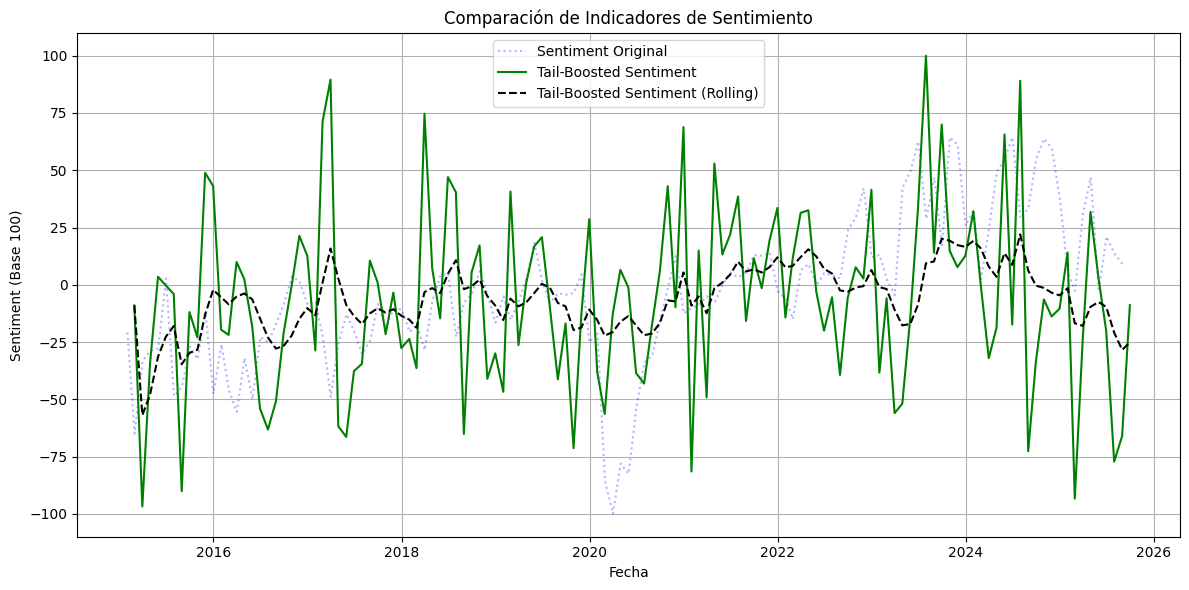

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(sentiment.index.to_timestamp(), sentiment['Sentiment'], label='Sentiment Z-Score', color='blue', linestyle=':', alpha = 0.2)
plt.plot(tail_boosted_sentiment_indicator.index, tail_boosted_sentiment_indicator.iloc[:,0], label='Tail-Boosted Sentiment', color='green', alpha = 0.7)
plt.plot(tail_boosted_sentiment_indicator.index, tail_boosted_sentiment_indicator.iloc[:,0].ewm(5).mean(), label='Tail-Boosted Sentiment (Rolling)', color='black', alpha = 1, linestyle='--')
plt.title('Comparación de Indicadores de Sentimiento')
plt.xlabel('Fecha')
plt.ylabel('Sentiment (Base 100)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()